# Naive Bayes playstore reviews

#### Paso 1: Carga del conjunto de datos

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv")

#### Paso 2: Estudio de variables y su contenido

In [2]:
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [3]:
df.info()
print(df.shape)
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB
(891, 3)
Index(['package_name', 'review', 'polarity'], dtype='str')


In [4]:
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())

package_name    0
review          0
polarity        0
dtype: int64
Duplicados: 0


In [5]:
df = df.drop(columns=["package_name"])
df.head()

,review,polarity
0,privacy at least put some option appear offli...,0
1,"messenger issues ever since the last update, ...",0
2,profile any time my wife or anybody has more ...,0
3,the new features suck for those of us who don...,0
4,forced reload on uploading pic on replying co...,0


In [6]:
df["review"] = df["review"].astype(str).str.strip().str.lower()
df.head()

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0


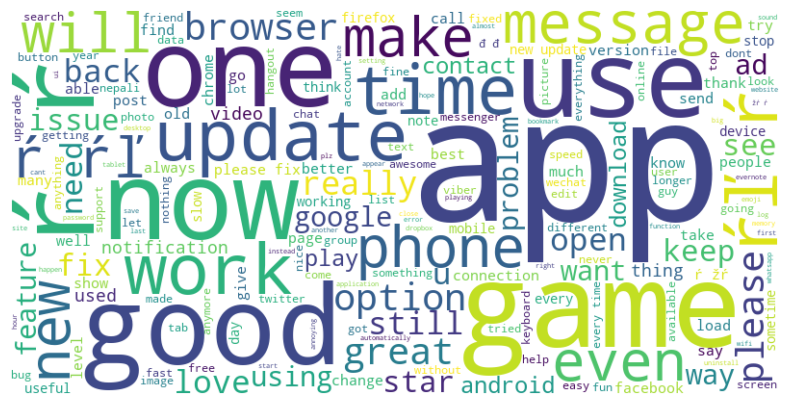

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

txt = " ".join(str(review) for review in df["review"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(txt)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["polarity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

485    best app i can't believe that it is free! they...
622    good good for slow connection this uc minilite...
854    #1 great game. challenging to the point where ...
536    very reliable syncing but......the web ui look...
728    didn't work couldn't use it with my note 4, it...
Name: review, dtype: str

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vec_model = CountVectorizer(stop_words="english")

X_train_vec = vec_model.fit_transform(X_train)
X_test_vec = vec_model.transform(X_test)

print(X_train_vec.shape)
print(X_test_vec.shape)

(712, 3272)
(179, 3272)


#### Paso 3: Construye un naive bayes

A) MultinomialNB

In [10]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB

model_multinomial = MultinomialNB()
model_multinomial.fit(X_train_vec, y_train)

y_pred_multi = model_multinomial.predict(X_test_vec)

print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_multi))
print(classification_report(y_test, y_pred_multi))

MultinomialNB Accuracy: 0.8547486033519553
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       117
           1       0.89      0.66      0.76        62

    accuracy                           0.85       179
   macro avg       0.87      0.81      0.83       179
weighted avg       0.86      0.85      0.85       179



B) BernoulliNB

In [11]:
from sklearn.naive_bayes import BernoulliNB

model_bernoulli = BernoulliNB()
model_bernoulli.fit(X_train_vec, y_train)

y_pred_ber = model_bernoulli.predict(X_test_vec)

print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred_ber))
print(classification_report(y_test, y_pred_ber))

BernoulliNB Accuracy: 0.7821229050279329
              precision    recall  f1-score   support

           0       0.76      0.97      0.85       117
           1       0.87      0.44      0.58        62

    accuracy                           0.78       179
   macro avg       0.82      0.70      0.72       179
weighted avg       0.80      0.78      0.76       179



C) GaussianNB

In [12]:
from sklearn.naive_bayes import GaussianNB

model_gaussian = GaussianNB()
model_gaussian.fit(X_train_vec.toarray(), y_train)

y_pred_gau = model_gaussian.predict(X_test_vec.toarray())

print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gau))
print(classification_report(y_test, y_pred_gau))

GaussianNB Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       117
           1       0.76      0.68      0.72        62

    accuracy                           0.82       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.81      0.82      0.81       179



#### Comparar resultados

In [13]:
results = pd.DataFrame({
    "Modelo": ["MultinomialNB", "BernoulliNB", "GaussianNB"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_multi),
        accuracy_score(y_test, y_pred_ber),
        accuracy_score(y_test, y_pred_gau)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Modelo,Accuracy
0,MultinomialNB,0.854749
2,GaussianNB,0.815642
1,BernoulliNB,0.782123


#### Paso 4: Optimiza el modelo anterior

In [19]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

model = MultinomialNB()

hyperparams = {
    "alpha": np.linspace(0.001, 5.0, 200),
    "fit_prior": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=hyperparams,
    n_iter=50,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)


In [20]:
random_search.fit(X_train_vec, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': array([1.0000...00000000e+00]), 'fit_prior': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to

In [21]:
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Best parameters: {'fit_prior': False, 'alpha': np.float64(1.7594422110552763)}
Best CV score: 0.803378311829016


#### Paso 5: Guarda el modelo

In [16]:
from pickle import dump

dump(model_multinomial, open("../models/multinomial_nb_playstore_reviews.plk", "wb"))

#### Paso 6: Explora otras alternativas

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_vec, y_train)
y_pred_rf = rf_model.predict(X_test_vec)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7653631284916201
              precision    recall  f1-score   support

           0       0.75      0.97      0.84       117
           1       0.88      0.37      0.52        62

    accuracy                           0.77       179
   macro avg       0.81      0.67      0.68       179
weighted avg       0.79      0.77      0.73       179



In [18]:
final_results = pd.DataFrame({
    "Modelo": ["MultinomialNB", "BernoulliNB", "GaussianNB", "RandomForest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_multi),
        accuracy_score(y_test, y_pred_ber),
        accuracy_score(y_test, y_pred_gau),
        accuracy_score(y_test, y_pred_rf)
    ]
})

final_results.sort_values(by="Accuracy", ascending=False)

,Modelo,Accuracy
0,MultinomialNB,0.854749
2,GaussianNB,0.815642
1,BernoulliNB,0.782123
3,RandomForest,0.765363
